<a href="https://colab.research.google.com/github/surya323-ma/-QuantAI-Lab-AI-Quantitative-Modeling-Playground/blob/main/Smart%20Backtesting%20Engine%20/%20Smart_Backtesting_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
N = 500
mu = 0.0005  # Drift
sigma = 0.01  # Volatility



# --- Generate Synthetic Stock Price Data (Random Walk) ---

In [3]:
returns = np.random.normal(loc=mu, scale=sigma, size=N)
price = 100 * np.exp(np.cumsum(returns))
dates = pd.date_range(start="2020-01-01", periods=N)
df = pd.DataFrame({'Price': price}, index=dates)



# --- Create ML Signal: Moving Average Crossover ---

In [4]:
short_window = 20
long_window = 50
df['MA_Short'] = df['Price'].rolling(window=short_window, min_periods=1).mean()
df['MA_Long'] = df['Price'].rolling(window=long_window, min_periods=1).mean()
df['Signal'] = 0
df.loc[df['MA_Short'] > df['MA_Long'], 'Signal'] = 1  # Buy
# Sell signal when short MA crosses below long MA
df.loc[df['MA_Short'] < df['MA_Long'], 'Signal'] = -1  # Sell

df['Position'] = df['Signal'].shift(1).fillna(0)


In [5]:
# --- Simulate Trading Strategy ---
df['Market_Return'] = df['Price'].pct_change().fillna(0)
df['Strategy_Return'] = df['Position'] * df['Market_Return']
df['Equity_Curve'] = (1 + df['Strategy_Return']).cumprod()

# --- Calculate Cumulative Returns ---
df['Cumulative_Return'] = df['Equity_Curve'] - 1

# --- Calculate Drawdown ---
df['Rolling_Max'] = df['Equity_Curve'].cummax()
df['Drawdown'] = df['Equity_Curve'] / df['Rolling_Max'] - 1

# --- Smoothed Trend Line (Rolling Mean) ---
df['Trend'] = df['Price'].rolling(window=30, min_periods=1).mean()

# --- Plotting ---

In [10]:
plt.figure(figsize=(14, 20))

<Figure size 1400x2000 with 0 Axes>

<Figure size 1400x2000 with 0 Axes>

# 1. Price with Buy/Sell Signals and Trend

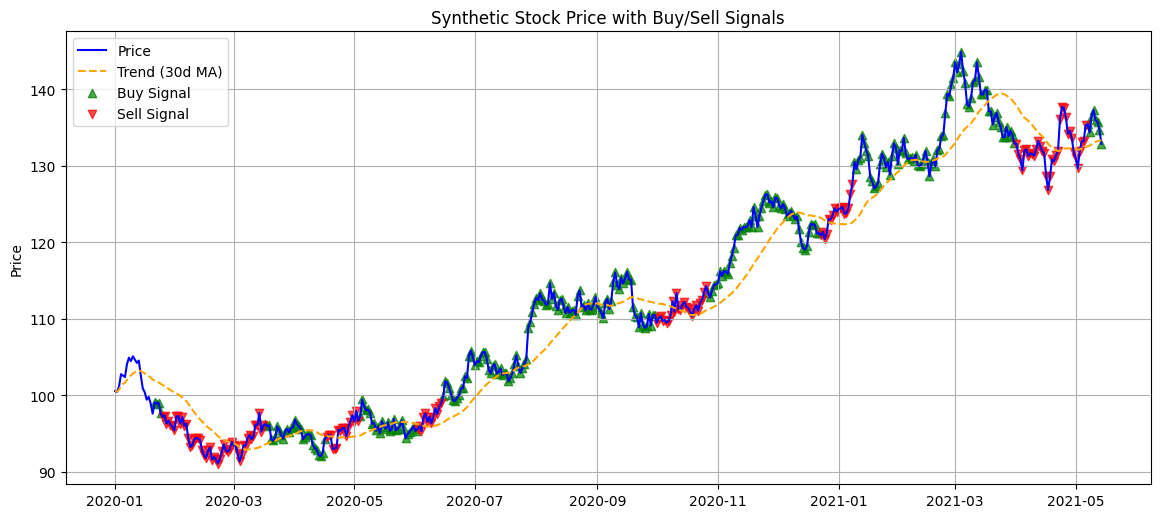

In [13]:
plt.figure(figsize=(14, 20))
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Price'], label='Price', color='blue')
plt.plot(df.index, df['Trend'], label='Trend (30d MA)', color='orange', linestyle='--')
buys = df[df['Signal'] == 1]
sells = df[df['Signal'] == -1]
plt.scatter(buys.index, buys['Price'], marker='^', color='green', label='Buy Signal', alpha=0.7)
plt.scatter(sells.index, sells['Price'], marker='v', color='red', label='Sell Signal', alpha=0.7)
plt.title('Synthetic Stock Price with Buy/Sell Signals')
plt.ylabel('Price')
plt.legend()
plt.grid(True)


# 2. Equity Curve

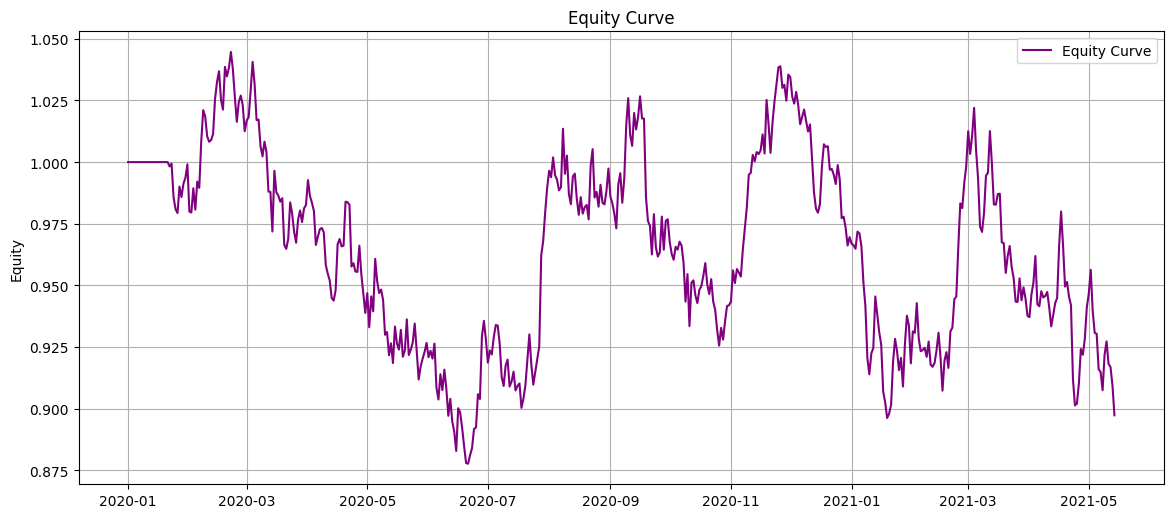

In [14]:
plt.figure(figsize=(14, 20))
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Equity_Curve'], label='Equity Curve', color='purple')
plt.title('Equity Curve')
plt.ylabel('Equity')
plt.legend()
plt.grid(True)


# 3. Drawdown Curve

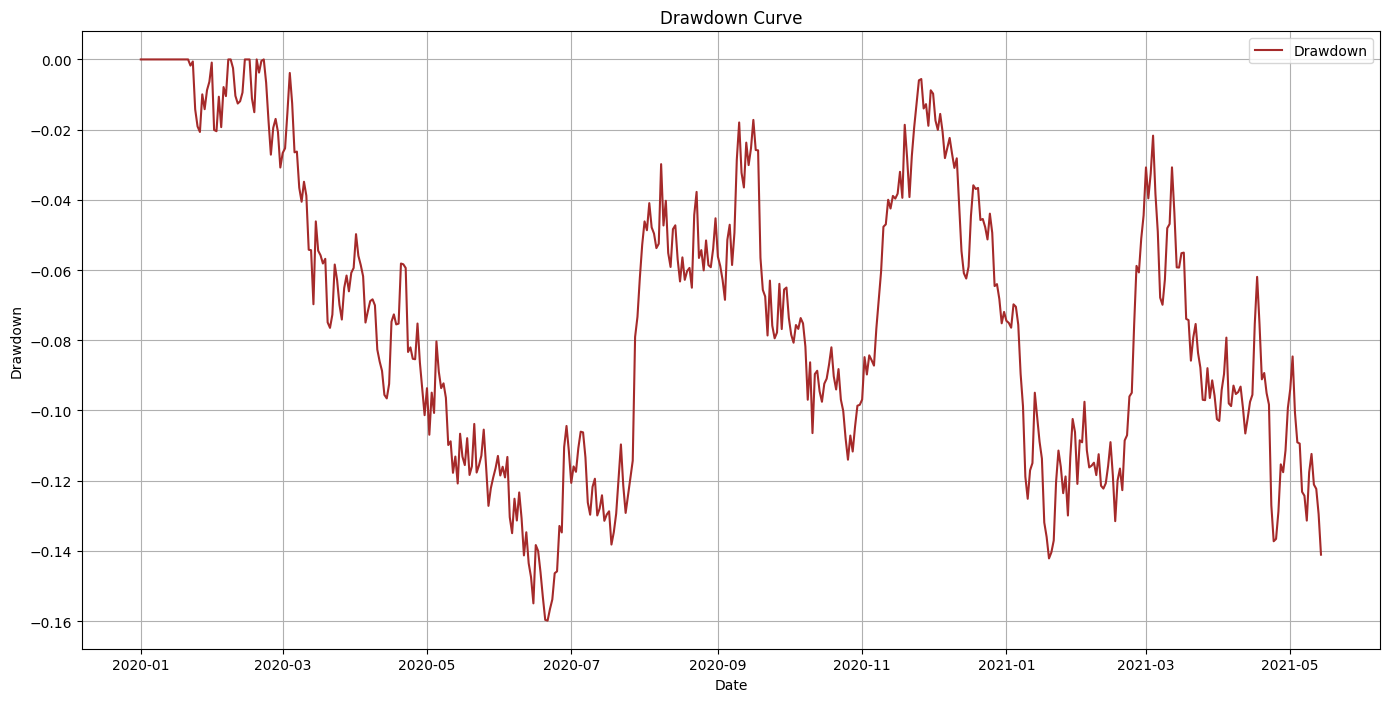

In [15]:
plt.figure(figsize=(14, 20))
plt.subplot(3, 1, 3)
plt.plot(df.index, df['Drawdown'], label='Drawdown', color='brown')
plt.title('Drawdown Curve')
plt.ylabel('Drawdown')
plt.xlabel('Date')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()